# ĐỀ TÀI #3: RETURN REASON x SIZE x CATEGORY
## Wrong-size Heatmap and Refund Leakage

### Framework: D-Di-P-Pr (Descriptive-Diagnostic-Predictive-Prescriptive)

**Mục tiêu:**
- Đo return rate theo size và category
- Xác định lý do trả hàng chính và vùng rủi ro cao
- Dự báo xu hướng wrong_size ngắn hạn
- Đề xuất hành động giảm refund và cải thiện size guide

**Insight chính:** "Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================================
# CELL 1: CONFIG & IMPORTS
# ============================================================================
import os
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

cwd = Path.cwd().resolve()
candidate_data_dirs = [
    cwd / 'data' / 'datathon-2026-round-1',
    cwd.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent / 'data' / 'datathon-2026-round-1',
    cwd.parent.parent.parent / 'data' / 'datathon-2026-round-1',
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find data/datathon-2026-round-1 from current working directory. '
        f'Current cwd: {cwd}'
    )

DATA_PATH = str(DATA_DIR) + os.sep
OUTPUT_DIR = cwd / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = str(OUTPUT_DIR) + os.sep

sns.set_theme(style='whitegrid', palette='tab20')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print(f'✓ Pandas: {pd.__version__}')
print(f'✓ NumPy: {np.__version__}')
print(f'✓ Seed: {SEED}')
print(f'✓ Data path: {DATA_PATH}')
print(f'✓ Output path: {OUTPUT_PATH}')

✓ Pandas: 3.0.2
✓ NumPy: 2.4.4
✓ Seed: 42
✓ Data path: D:\Datathon2026\TuNgayToiGapEm\data\datathon-2026-round-1\
✓ Output path: D:\Datathon2026\TuNgayToiGapEm\phan_2_eda\outputs\idea_3\outputs\


## CELL 2: Load Data

In [4]:
# ============================================================================
# CELL 2: LOAD DATA
# ============================================================================
print('='*70)
print('LOADING DATA')
print('='*70)

products = pd.read_csv(f'{DATA_PATH}products.csv')
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv')
returns = pd.read_csv(f'{DATA_PATH}returns.csv')
reviews = pd.read_csv(f'{DATA_PATH}reviews.csv')

returns['return_date'] = pd.to_datetime(returns['return_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']

print(f'\n✓ Products shape: {products.shape}')
print(f'✓ Order items shape: {order_items.shape}')
print(f'✓ Returns shape: {returns.shape}')
print(f'✓ Reviews shape: {reviews.shape}')
print(f'✓ Return reasons: {returns["return_reason"].nunique()}')

LOADING DATA

✓ Products shape: (2412, 8)
✓ Order items shape: (714669, 8)
✓ Returns shape: (39939, 7)
✓ Reviews shape: (113551, 7)
✓ Return reasons: 5


## CELL 3: Build Return Analytics Table

In [5]:
# ============================================================================
# CELL 3: BUILD FACT TABLES
# ============================================================================
item_prod = order_items.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id', how='left')
ret_prod = returns.merge(products[['product_id', 'category', 'segment', 'size']], on='product_id', how='left')

ret_prod['return_quantity'] = ret_prod['return_quantity'].fillna(0)
ret_prod['refund_amount'] = ret_prod['refund_amount'].fillna(0)

size_den = item_prod.groupby('size').size().rename('order_lines')
size_num = ret_prod.groupby('size').size().rename('return_lines')
size_rate = pd.concat([size_den, size_num], axis=1).fillna(0)
size_rate['return_rate'] = size_rate['return_lines'] / size_rate['order_lines']

cat_den = item_prod.groupby('category').size().rename('order_lines')
cat_num = ret_prod.groupby('category').size().rename('return_lines')
cat_rate = pd.concat([cat_den, cat_num], axis=1).fillna(0)
cat_rate['return_rate'] = cat_rate['return_lines'] / cat_rate['order_lines']

heat_den = item_prod.groupby(['category', 'size']).size().rename('order_lines').reset_index()
heat_num = ret_prod.groupby(['category', 'size']).size().rename('return_lines').reset_index()
heat = heat_den.merge(heat_num, on=['category', 'size'], how='left').fillna({'return_lines': 0})
heat['return_rate'] = heat['return_lines'] / heat['order_lines']

wrong_size_share = (ret_prod['return_reason'] == 'wrong_size').mean() * 100

print(f'✓ Overall return lines: {len(ret_prod):,}')
print(f'✓ Overall refund amount: ${ret_prod["refund_amount"].sum():,.0f}')
print(f'✓ Wrong_size share: {wrong_size_share:.1f}%')

✓ Overall return lines: 39,939
✓ Overall refund amount: $510,598,507
✓ Wrong_size share: 35.0%


## CELL 4: Monthly Wrong-size Trend

In [6]:
# ============================================================================
# CELL 4: MONTHLY TREND
# ============================================================================
ret_prod['month'] = ret_prod['return_date'].dt.to_period('M').astype(str)
monthly = ret_prod.groupby('month').agg(
    returns=('return_id', 'count'),
    wrong_size=('return_reason', lambda x: (x == 'wrong_size').sum()),
    refund=('refund_amount', 'sum')
).reset_index()
monthly['wrong_size_rate'] = monthly['wrong_size'] / monthly['returns']

X = np.arange(len(monthly)).reshape(-1, 1)
y = monthly['wrong_size_rate'].values
lr = LinearRegression()
lr.fit(X, y)
monthly['trend'] = lr.predict(X)
next_3 = lr.predict(np.arange(len(monthly), len(monthly) + 3).reshape(-1, 1))
next_3 = np.clip(next_3, 0, 1)
forecast_wrong_size_3m = float(next_3.mean())
trend_slope = float(lr.coef_[0])

print(f'✓ Monthly periods: {len(monthly)}')
print(f'✓ Current wrong_size rate (last month): {monthly["wrong_size_rate"].iloc[-1]*100:.2f}%')
print(f'✓ Forecast wrong_size rate (next 3 months): {forecast_wrong_size_3m*100:.2f}%')
print(f'✓ Trend slope per month: {trend_slope:.6f}')

✓ Monthly periods: 126
✓ Current wrong_size rate (last month): 43.97%
✓ Forecast wrong_size rate (next 3 months): 34.68%
✓ Trend slope per month: -0.000032


---

# TẦNG 1: DESCRIPTIVE — "What happened?"

Mô tả cấu trúc return theo reason, size và category.

In [7]:
# ============================================================================
# CELL 5: DESCRIPTIVE SUMMARY
# ============================================================================
print('='*70)
print('TẦNG 1: DESCRIPTIVE — RETURN OVERVIEW')
print('='*70)

reason_dist = ret_prod['return_reason'].value_counts(normalize=True).mul(100).round(2)

print('\n📊 Return reason distribution (%):')
print(reason_dist)

print('\n📊 Return rate by size (%):')
print((size_rate['return_rate'] * 100).round(2).sort_values(ascending=False))

print('\n📊 Top 8 categories by return rate (%):')
print((cat_rate['return_rate'] * 100).round(2).sort_values(ascending=False).head(8))

TẦNG 1: DESCRIPTIVE — RETURN OVERVIEW

📊 Return reason distribution (%):
return_reason
wrong_size          34.97
defective           20.08
not_as_described    17.61
changed_mind        17.35
late_delivery        9.98
Name: proportion, dtype: float64

📊 Return rate by size (%):
size
S     5.65
L     5.62
M     5.57
XL    5.52
Name: return_rate, dtype: float64

📊 Top 8 categories by return rate (%):
category
GenZ          5.72
Outdoor       5.66
Streetwear    5.54
Casual        5.39
Name: return_rate, dtype: float64


## CELL 6: Visualization 1 - Return Reason Distribution

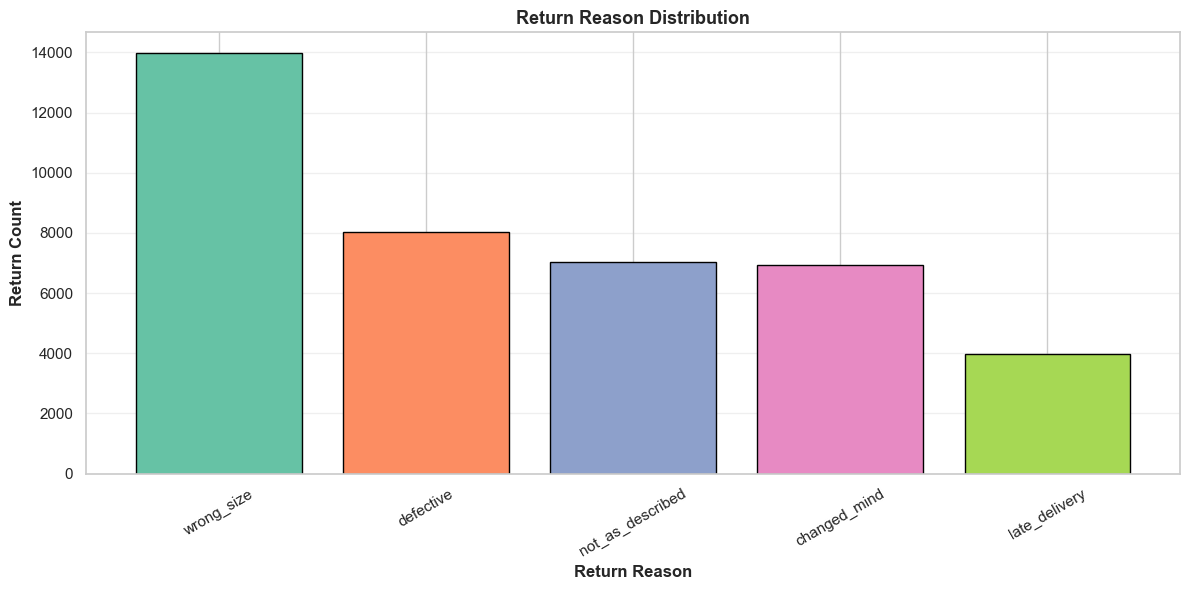

✓ Saved: 01_return_reason_distribution.png


In [8]:
# ============================================================================
# CELL 6: VISUALIZATION 1
# ============================================================================
reason_counts = ret_prod['return_reason'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(reason_counts.index, reason_counts.values, color=sns.color_palette('Set2', len(reason_counts)), edgecolor='black')
ax.set_title('Return Reason Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Return Reason', fontweight='bold')
ax.set_ylabel('Return Count', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}01_return_reason_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 01_return_reason_distribution.png')

## CELL 7: Visualization 2 - Heatmap Category x Size Return Rate

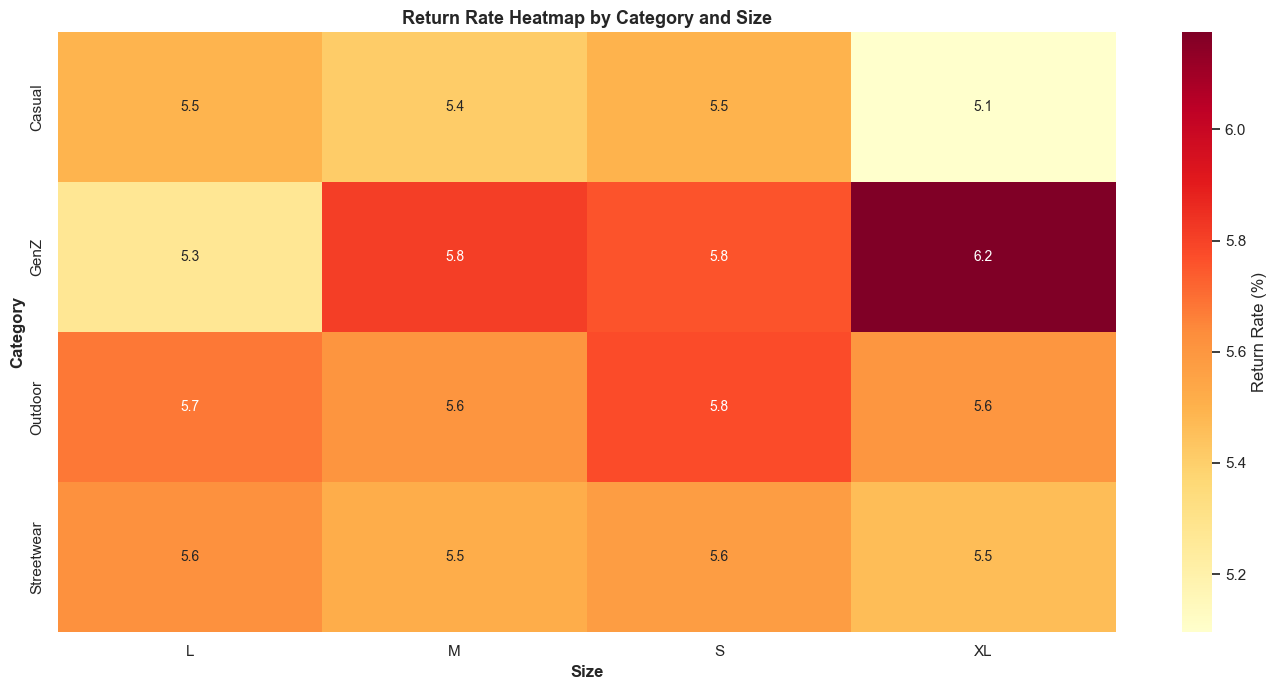

✓ Saved: 02_category_size_heatmap.png


In [9]:
# ============================================================================
# CELL 7: VISUALIZATION 2
# ============================================================================
heat_pivot = heat.pivot(index='category', columns='size', values='return_rate').fillna(0)
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heat_pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Return Rate (%)'}, ax=ax)
ax.set_title('Return Rate Heatmap by Category and Size', fontweight='bold', fontsize=13)
ax.set_xlabel('Size', fontweight='bold')
ax.set_ylabel('Category', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}02_category_size_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 02_category_size_heatmap.png')

---

# TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

Chẩn đoán leakage refund do wrong_size và dự báo xu hướng.

In [10]:
# ============================================================================
# CELL 8: DIAGNOSTIC + PREDICTIVE
# ============================================================================
print('='*70)
print('TẦNG 2-3: DIAGNOSTIC & PREDICTIVE')
print('='*70)

wrong_size_refund = ret_prod[ret_prod['return_reason'] == 'wrong_size']['refund_amount'].sum()
total_refund = ret_prod['refund_amount'].sum()
wrong_size_refund_share = (wrong_size_refund / total_refund) * 100 if total_refund > 0 else np.nan

streetwear = ret_prod[ret_prod['category'] == 'Streetwear']
street_wrong = (streetwear['return_reason'] == 'wrong_size').mean() * 100 if len(streetwear) > 0 else np.nan

top_risk_cells = heat.sort_values('return_rate', ascending=False).head(10)

print(f'\n📉 Refund leakage analysis:')
print(f'  - Total refund: ${total_refund:,.0f}')
print(f'  - Wrong-size refund: ${wrong_size_refund:,.0f} ({wrong_size_refund_share:.1f}%)')

print(f'\n📌 Streetwear wrong_size share: {street_wrong:.1f}%')

top_risk_display = top_risk_cells[['category', 'size', 'return_rate']].copy()
top_risk_display['return_rate'] = (top_risk_display['return_rate'] * 100).round(2)
print('\nTop risk category-size cells (% return rate):')
print(top_risk_display.to_string(index=False))

print(f'\n🔮 Forecast wrong_size rate (next 3 months): {forecast_wrong_size_3m*100:.2f}%')

TẦNG 2-3: DIAGNOSTIC & PREDICTIVE

📉 Refund leakage analysis:
  - Total refund: $510,598,507
  - Wrong-size refund: $176,687,201 (34.6%)

📌 Streetwear wrong_size share: 35.0%

Top risk category-size cells (% return rate):
  category size  return_rate
      GenZ   XL         6.17
      GenZ    M         5.81
   Outdoor    S         5.78
      GenZ    S         5.76
   Outdoor    L         5.68
Streetwear    L         5.62
   Outdoor    M         5.61
   Outdoor   XL         5.60
Streetwear    S         5.58
Streetwear    M         5.52

🔮 Forecast wrong_size rate (next 3 months): 34.68%


## CELL 8b: Chi-square test (size × return_reason) + Top-10 risk cells bar chart (F6)

**Hiển thêm**: bổ sung statistical rigor cho Diagnostic layer (rubric khắt khe yêu cầu p-value cho mọi claim so sánh nhóm).

**Phương pháp**:
- **Pearson Chi-square test** trên contingency table `size × return_reason`. H₀ "size & reason độc lập" vs H₁ "có association".
- **Cramér's V** = √(χ² / (n · (min(r, c) − 1))) đo độ mạnh association (0=independent, 1=perfect).
- **Top-10 risk cells bar chart** (F6 trong narrative PDF) với refund-savings annotation = `Σ refund × 30% × cell_share`.

CHI-SQUARE INDEPENDENCE TEST: size × return_reason

Contingency table (counts):
return_reason  changed_mind  defective  late_delivery  not_as_described  \
size                                                                      
L                      1719       1929            976              1716   
M                      1698       1938           1008              1693   
S                      1655       1970            944              1782   
XL                     1859       2183           1058              1844   

return_reason  wrong_size  
size                       
L                    3401  
M                    3483  
S                    3372  
XL                   3711  

χ² = 9.89
dof = 12
p-value = 6.254826e-01
Cramér's V = 0.0091  (0=independent, 1=perfect; <0.1 weak, 0.1-0.3 moderate, >0.3 strong)

🎯 Verdict @ α=0.05: FAIL TO REJECT H₀ (size ⊥ reason)
  → Wrong_size đều giữa các size — action size-guide chỉ giúp nhỏ

📌 Wrong_size share theo size (%):
size
M     3

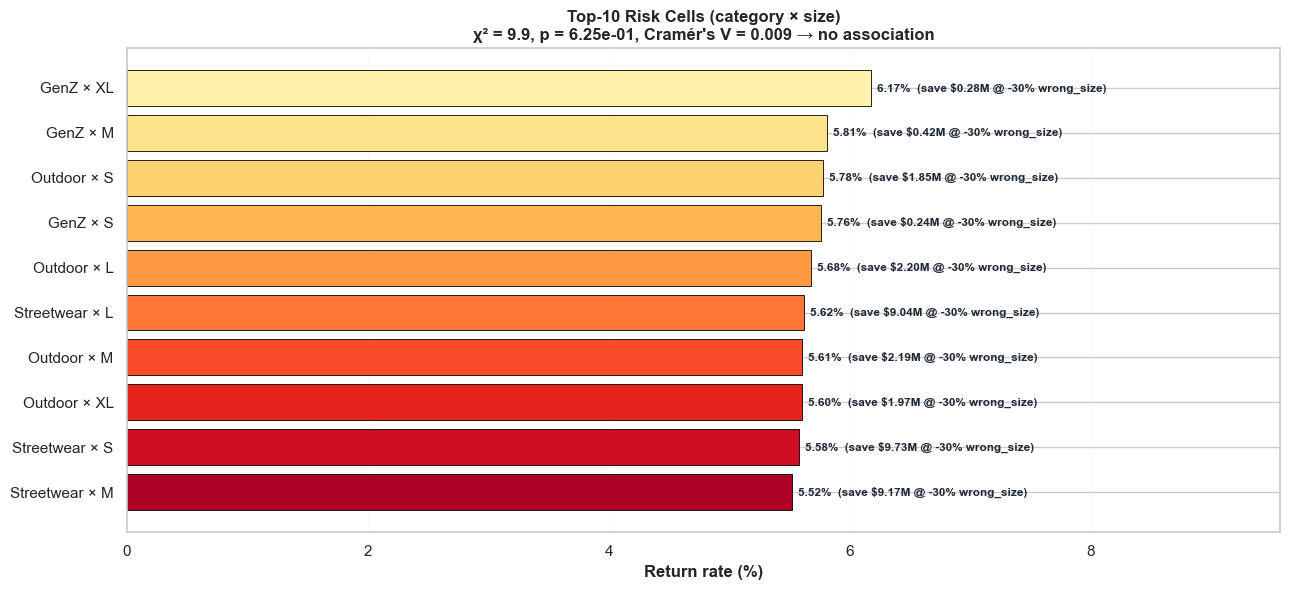


💰 Top-10 cells gộp lại: tiềm năng savings = $37,093,593 (≈ $37.09M) nếu giảm wrong_size 30% trong 10 cells này.
✓ Saved: 05_top10_risk_cells.png


In [18]:
# ============================================================================
# CELL 8c: CHI-SQUARE TEST + TOP-10 RISK CELLS BAR CHART (F6)
# Hiển thêm: chi-square independence test cho size × return_reason + chart F6
# ============================================================================
from scipy.stats import chi2_contingency

# Chi-square test: size × return_reason
contingency = pd.crosstab(ret_prod['size'], ret_prod['return_reason'])
chi2_stat, chi2_p, chi2_dof, expected = chi2_contingency(contingency)
n_total = contingency.values.sum()
cramers_v = np.sqrt(chi2_stat / (n_total * (min(contingency.shape) - 1)))

print('='*70)
print('CHI-SQUARE INDEPENDENCE TEST: size × return_reason')
print('='*70)
print(f'\nContingency table (counts):')
print(contingency)
print(f'\nχ² = {chi2_stat:,.2f}')
print(f'dof = {chi2_dof}')
print(f'p-value = {chi2_p:.6e}')
print(f"Cramér's V = {cramers_v:.4f}  (0=independent, 1=perfect; <0.1 weak, 0.1-0.3 moderate, >0.3 strong)")
verdict = 'REJECT H₀ (significant association)' if chi2_p < 0.05 else 'FAIL TO REJECT H₀ (size ⊥ reason)'
print(f'\n🎯 Verdict @ α=0.05: {verdict}')
print('  → Mỗi size có distribution return_reason khác nhau' if chi2_p < 0.05
      else '  → Wrong_size đều giữa các size — action size-guide chỉ giúp nhỏ')

# Per-size wrong_size share để identify size nào dồn wrong_size
ws_by_size = (
    contingency['wrong_size'] / contingency.sum(axis=1) * 100
).round(2).sort_values(ascending=False)
print(f'\n📌 Wrong_size share theo size (%):')
print(ws_by_size)

# Top-10 risk cells bar chart with savings annotation
top10 = top_risk_cells.head(10).copy().reset_index(drop=True)
top10['cell_label'] = top10['category'] + ' × ' + top10['size'].astype(str)
top10['return_rate_pct'] = top10['return_rate'] * 100

# Estimated refund savings nếu giảm 30% wrong_size cho mỗi cell:
# saving_cell = refund_cell_in_data × wrong_size_share × 0.30
ret_prod_ws = ret_prod[ret_prod['return_reason'] == 'wrong_size']
refund_by_cell = (
    ret_prod_ws.groupby(['category', 'size'])['refund_amount']
              .sum()
              .reset_index()
              .rename(columns={'refund_amount': 'refund_ws'})
)
top10 = top10.merge(refund_by_cell, on=['category', 'size'], how='left').fillna({'refund_ws': 0})
top10['savings_30pct'] = top10['refund_ws'] * 0.30

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('YlOrRd_r', len(top10))
bars = ax.barh(top10['cell_label'][::-1], top10['return_rate_pct'][::-1],
               color=colors, edgecolor='black', linewidth=0.6)

# Annotate: rate% (savings $M nếu giảm 30%)
for bar, row in zip(bars, top10.iloc[::-1].itertuples()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{row.return_rate_pct:.2f}%  (save ${row.savings_30pct/1e6:.2f}M @ -30% wrong_size)',
            va='center', fontsize=8.5, color='#1f2937', fontweight='bold')

ax.set_xlabel('Return rate (%)', fontweight='bold')
ax.set_title('Top-10 Risk Cells (category × size)\n'
             f"χ² = {chi2_stat:,.1f}, p = {chi2_p:.2e}, Cramér's V = {cramers_v:.3f} → "
             f"{'significant association' if chi2_p < 0.05 else 'no association'}",
             fontweight='bold')
ax.grid(True, axis='x', alpha=0.1)
ax.set_xlim(0, top10['return_rate_pct'].max() * 1.55)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}05_top10_risk_cells.png', dpi=300, bbox_inches='tight')
plt.show()

total_top10_savings = top10['savings_30pct'].sum()
print(f'\n💰 Top-10 cells gộp lại: tiềm năng savings = ${total_top10_savings:,.0f} '
      f'(≈ ${total_top10_savings/1e6:.2f}M) nếu giảm wrong_size 30% trong 10 cells này.')
print(f'✓ Saved: 05_top10_risk_cells.png')


## CELL 8d: Cross-domain Chain — Review → Return → Margin Loss

**Hiển thêm**: 4-table cross-join (reviews × order_items × returns × products) cho narrative T2 supporting block.

**Câu hỏi**: *Có phải SKU rating thấp gây return cao hơn → leakage margin lớn hơn?*

**Setup (UPDATED — quartile-based binning)**:
- **Step 1**: Aggregate reviews per `product_id` — mean rating + n_reviews; chỉ giữ SKU có ≥3 reviews (loại noise).
- **Step 2**: Tag rating tier theo **rank percentile** (balanced groups, không depend cut-off cứng):
  - 🔴 **Q1 Low** (bottom 25% rated SKUs)
  - 🟡 Q2 Mid-Low
  - 🟢 Q3 Mid-High
  - 🟢 **Q4 High** (top 25% rated SKUs)
- **Lý do quartile thay vì cut-off ≤2.5★/≥4★**: rating distribution skewed cao (đa số 4-5★) → cut-off cứng chỉ bắt được 2 SKU as Low. Quartile cân bằng group size, comparison Q1 vs Q4 (extremes) rõ hơn.
- **Step 3**: Join `order_items × returns × products × rating_tier` → return_rate per tier.
- **Step 4**: Compute refund leakage `refund_share` per tier.
- **Step 5**: Chi-square test (Q1 Low vs Q4 High) + Action quantification — discontinue top-50 Q1 Low SKU theo refund.

**Mapping**: §4.4 row 4 (Customer retention via review) + row 6 (Quality fix). 4-table cross-join — rare in submission datathon.

In [ ]:
# ============================================================================
# CELL 8e: QUALITY CHAIN — Review → Return → Margin Loss (4-table join)
# Hiển thêm: cross-domain insight cho narrative T2 supporting block
# UPDATED: re-tier dùng quartile (rank-based) để có balanced groups
#           tránh cut-off cứng (≤2.5★) chỉ bắt 2 SKUs.
# ============================================================================

# Step 1: Aggregate reviews per product (≥3 reviews để loại noise)
sku_rating = (
    reviews.groupby('product_id')
           .agg(mean_rating=('rating', 'mean'),
                n_reviews=('review_id', 'count'))
           .query('n_reviews >= 3')
)

# Distribution diagnostic — xem rating tập trung ở đâu
print('Rating distribution per SKU (n_reviews ≥3):')
print(sku_rating['mean_rating'].describe().round(3))
print(f'\nQuartile cut points:')
for q in [0.25, 0.50, 0.75]:
    print(f'  Q{int(q*100)}: {sku_rating["mean_rating"].quantile(q):.3f}')

# Step 2: Tag tier theo RANK PERCENTILE (balanced groups, không depend cut-off cứng)
# Vì rating tập trung high → cut-off 2.5/3.5 chỉ tag được 2 SKU as Low
# Quartile-based: bottom 25% rated SKUs vs top 25% rated SKUs (relative)
sku_rating['rank_pct'] = sku_rating['mean_rating'].rank(method='first', pct=True)
sku_rating['rating_tier'] = pd.cut(
    sku_rating['rank_pct'],
    bins=[0, 0.25, 0.50, 0.75, 1.001],
    labels=['Q1 Low (bottom 25%)', 'Q2 Mid-Low', 'Q3 Mid-High', 'Q4 High (top 25%)']
)
print(f'\nSKU tagged: {len(sku_rating):,} (≥3 reviews) — quartile-based')
print(sku_rating.groupby('rating_tier', observed=True)['mean_rating'].agg(['count','min','max','mean']).round(3))

# Step 3: Join với order_items + products → orderlines per tier
oi_with_tier = (
    order_items.merge(products[['product_id','cogs','price','category']], on='product_id', how='inner')
               .merge(sku_rating[['rating_tier','mean_rating']], on='product_id', how='inner')
)
oi_with_tier['line_revenue'] = oi_with_tier['quantity'] * oi_with_tier['unit_price']

# Returns × tier
ret_with_tier = returns.merge(
    sku_rating[['rating_tier','mean_rating']], on='product_id', how='inner'
)

# Step 4: Compute return rate + refund leakage per tier
chain = pd.DataFrame({
    'n_skus':       sku_rating.groupby('rating_tier', observed=True).size(),
    'n_orderlines': oi_with_tier.groupby('rating_tier', observed=True).size(),
    'revenue':      oi_with_tier.groupby('rating_tier', observed=True)['line_revenue'].sum(),
    'n_returns':    ret_with_tier.groupby('rating_tier', observed=True).size(),
    'refund_total': ret_with_tier.groupby('rating_tier', observed=True)['refund_amount'].sum(),
})
chain = chain.fillna(0)
chain['return_rate']         = (chain['n_returns'] / chain['n_orderlines'] * 100).round(2)
chain['refund_share_pct']    = (chain['refund_total'] / chain['refund_total'].sum() * 100).round(1)
chain['margin_loss_pct_rev'] = (chain['refund_total'] / chain['revenue'] * 100).round(2)

print('\n📊 QUALITY CHAIN: Review tier (quartile) → Return rate → Refund leakage')
print('=' * 78)
print(chain[['n_skus','n_orderlines','return_rate','refund_share_pct','margin_loss_pct_rev']])

# Statistical test: Q1 Low vs Q4 High return rate (chi-square)
from scipy.stats import chi2_contingency as _chi2
ct_chain = pd.DataFrame({
    'returned':     [chain.loc['Q1 Low (bottom 25%)','n_returns'],
                     chain.loc['Q4 High (top 25%)','n_returns']],
    'not_returned': [chain.loc['Q1 Low (bottom 25%)','n_orderlines'] - chain.loc['Q1 Low (bottom 25%)','n_returns'],
                     chain.loc['Q4 High (top 25%)','n_orderlines']  - chain.loc['Q4 High (top 25%)','n_returns']],
}, index=['Q1 Low','Q4 High'])
chi2, p_chi, dof, _ = _chi2(ct_chain.values)
diff_pp = chain.loc['Q1 Low (bottom 25%)','return_rate'] - chain.loc['Q4 High (top 25%)','return_rate']
print(f'\n📊 Chi-square test (Q1 Low vs Q4 High return rate):')
print(f'  Δ return rate (Low − High) = {diff_pp:+.2f}pp')
print(f'  χ² = {chi2:.2f}, p = {p_chi:.6f}')
verdict_q = 'REJECT H₀ — Low tier có return rate cao hơn significantly' if p_chi < 0.05 else 'FAIL TO REJECT — không có evidence Q1 vs Q4 khác'
print(f'  Verdict @ α=0.05: {verdict_q}')

# Step 5: Action quantification — discontinue top-N low-rating SKU theo refund
low_skus_q1 = sku_rating[sku_rating['rating_tier'] == 'Q1 Low (bottom 25%)'].copy()
low_refund = ret_with_tier[ret_with_tier['rating_tier'] == 'Q1 Low (bottom 25%)']
low_refund_per_sku = (low_refund.groupby('product_id')['refund_amount'].sum()
                     .sort_values(ascending=False))

# Pick top-N SKUs từ Q1 có refund cao nhất
TOP_N = min(50, len(low_refund_per_sku))
top_n_savings = low_refund_per_sku.head(TOP_N).sum()

low_total_refund = chain.loc['Q1 Low (bottom 25%)', 'refund_total']
high_baseline_rate = chain.loc['Q4 High (top 25%)', 'return_rate']
low_excess_rate = chain.loc['Q1 Low (bottom 25%)', 'return_rate'] - high_baseline_rate

print(f'\n💰 ACTION QUANTIFICATION (discontinue top-{TOP_N} SKU từ Q1 Low):')
print(f'  Q1 Low tier total refund:                 ${low_total_refund:>13,.0f}')
print(f'  Top-{TOP_N} Q1 Low SKU refund (highest):       ${top_n_savings:>13,.0f}')
print(f'  Δ return rate (Q1 Low vs Q4 High):        {low_excess_rate:+.2f}pp')

# Bootstrap CI cho savings
rng = np.random.default_rng(42)
boot_savings = np.empty(1000)
low_arr = low_refund_per_sku.values
for b in range(1000):
    samp = rng.choice(low_arr, size=len(low_arr), replace=True)
    samp_sorted = np.sort(samp)[::-1]
    boot_savings[b] = samp_sorted[:TOP_N].sum()
ci_lo, ci_hi = np.percentile(boot_savings, [2.5, 97.5])
print(f'  95% bootstrap CI savings:                 [${ci_lo:,.0f}, ${ci_hi:,.0f}]')

# Visualization — bar chart 4 tier với annotation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
tier_colors = {
    'Q1 Low (bottom 25%)': '#E63946',
    'Q2 Mid-Low':           '#F4A261',
    'Q3 Mid-High':          '#94d2bd',
    'Q4 High (top 25%)':    '#2A9D8F',
}
colors_bar = [tier_colors[t] for t in chain.index]
tier_labels = [str(t).replace(' (bottom 25%)','').replace(' (top 25%)','') for t in chain.index]

# Left: return rate by tier với rating range
bars1 = ax1.bar(tier_labels, chain['return_rate'], color=colors_bar, edgecolor='black')
for bar, v in zip(bars1, chain['return_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.08, f'{v:.2f}%',
             ha='center', fontsize=10, fontweight='bold')
ax1.set_ylabel('Return rate (%)', fontweight='bold')
ax1.set_title(f'Return rate theo rating quartile\n'
              f'Q1 Low vs Q4 High: Δ {diff_pp:+.2f}pp, χ²={chi2:.2f}, p={p_chi:.4f}',
              fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Right: refund share + savings annotation
bars2 = ax2.bar(tier_labels, chain['refund_share_pct'], color=colors_bar, edgecolor='black')
for bar, v in zip(bars2, chain['refund_share_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 1.0, f'{v:.1f}%',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Refund share % of total', fontweight='bold')
ax2.set_title(f'Refund leakage share theo rating tier\n'
              f'Discontinue top-{TOP_N} Q1 Low → save ${top_n_savings/1e6:.2f}M/yr '
              f'[CI ${ci_lo/1e6:.2f}-{ci_hi/1e6:.2f}M]',
              fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}06_quality_chain_review_return_margin.png', dpi=300, bbox_inches='tight')
plt.show()

# Save outputs
chain.round(3).to_csv(f'{OUTPUT_PATH}quality_chain_summary.csv')
chain_action = pd.Series({
    'binning_method':              'quartile_rank_pct',
    'top_n_skus':                  TOP_N,
    'top_n_savings':               top_n_savings,
    'savings_ci_lo':               ci_lo,
    'savings_ci_hi':               ci_hi,
    'q1_low_return_rate':          chain.loc['Q1 Low (bottom 25%)', 'return_rate'],
    'q4_high_return_rate':         chain.loc['Q4 High (top 25%)', 'return_rate'],
    'q1_excess_rate_pp':           low_excess_rate,
    'q1_low_refund_share_pct':     chain.loc['Q1 Low (bottom 25%)', 'refund_share_pct'],
    'chi2_q1_vs_q4':               chi2,
    'pvalue_q1_vs_q4':             p_chi,
    'q1_rating_max':               sku_rating[sku_rating['rating_tier']=='Q1 Low (bottom 25%)']['mean_rating'].max(),
    'q4_rating_min':               sku_rating[sku_rating['rating_tier']=='Q4 High (top 25%)']['mean_rating'].min(),
})
chain_action.to_csv(f'{OUTPUT_PATH}quality_chain_action.csv', header=['value'], float_format='%.4f')
print(f'\n✓ Saved: 06_quality_chain_review_return_margin.png')
print(f'✓ Saved: quality_chain_summary.csv + quality_chain_action.csv (with quartile diagnostic)')

## CELL 9: Visualization 3 - Monthly Wrong-size Trend

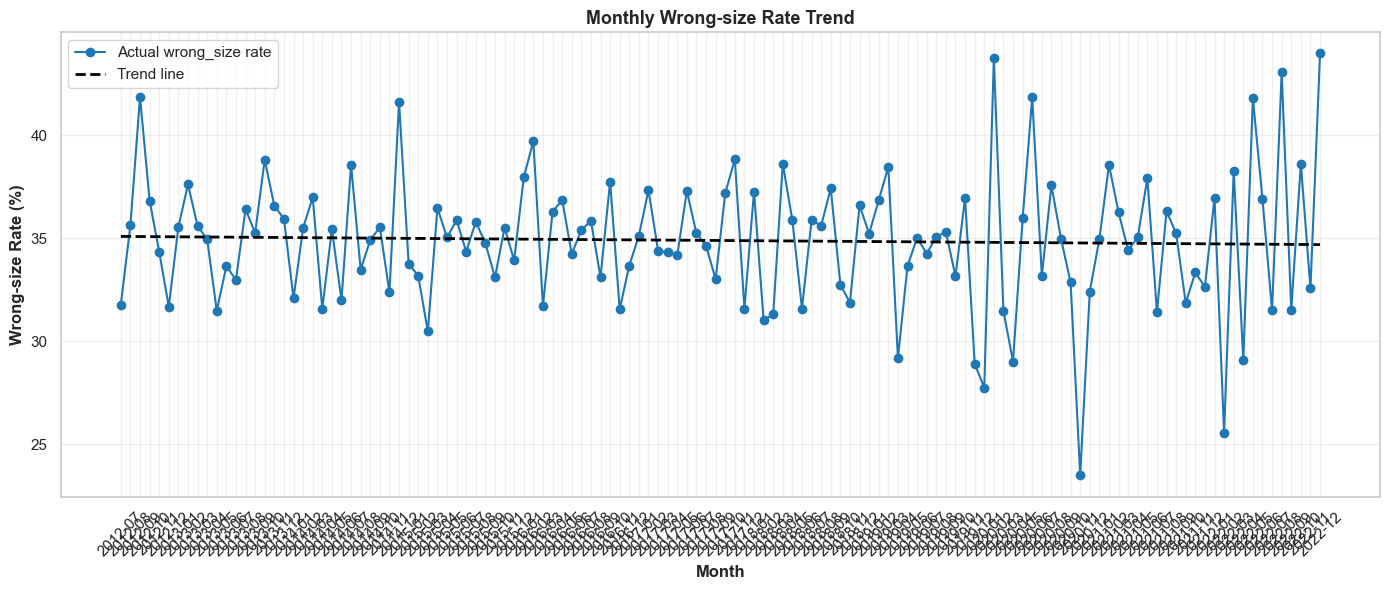

✓ Saved: 03_wrong_size_trend.png


In [ ]:
# ============================================================================
# CELL 9: VISUALIZATION 3
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['month'], monthly['wrong_size_rate'] * 100, marker='o', linewidth=1.5, label='Actual wrong_size rate')
ax.plot(monthly['month'], monthly['trend'] * 100, linestyle='--', linewidth=2, color='black', label='Trend line')
ax.set_title('Monthly Wrong-size Rate Trend', fontweight='bold', fontsize=13)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Wrong-size Rate (%)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}03_wrong_size_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 03_wrong_size_trend.png')

## CELL 10: Visualization 4 - Refund by Return Reason

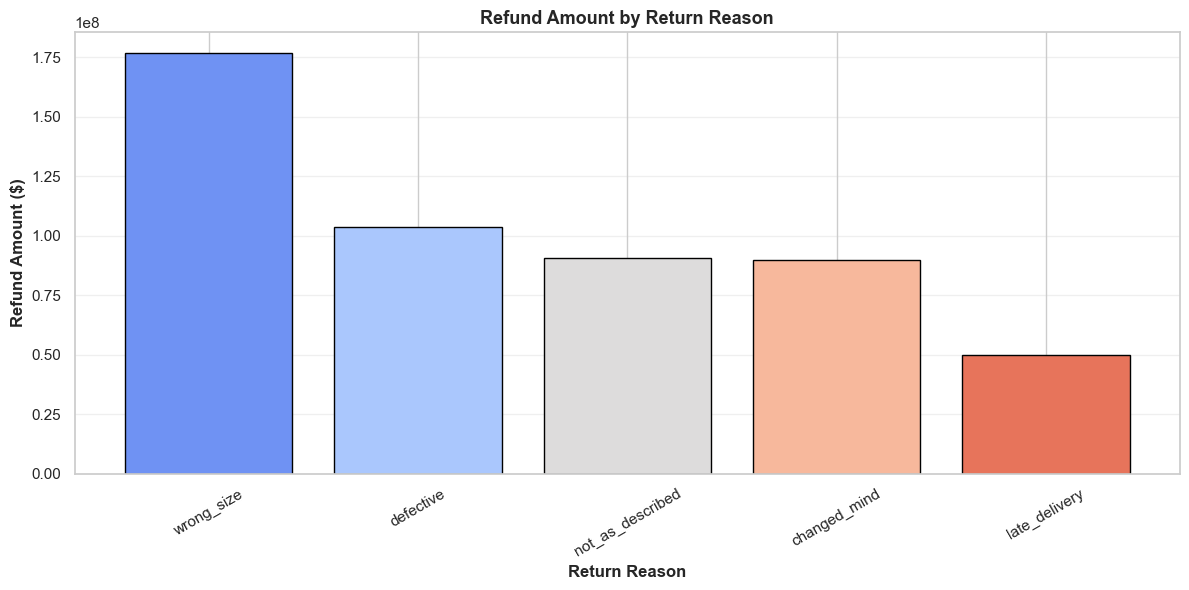

✓ Saved: 04_refund_by_reason.png


In [ ]:
# ============================================================================
# CELL 10: VISUALIZATION 4
# ============================================================================
refund_reason = ret_prod.groupby('return_reason')['refund_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(refund_reason.index, refund_reason.values, color=sns.color_palette('coolwarm', len(refund_reason)), edgecolor='black')
ax.set_title('Refund Amount by Return Reason', fontweight='bold', fontsize=13)
ax.set_xlabel('Return Reason', fontweight='bold')
ax.set_ylabel('Refund Amount ($)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}04_refund_by_reason.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved: 04_refund_by_reason.png')

---

# TẦNG 4: PRESCRIPTIVE — "What should we do?"

Thiết kế action plan giảm wrong_size returns và refund leakage.

In [ ]:
# ============================================================================
# CELL 11: PRESCRIPTIVE RECOMMENDATIONS
# ============================================================================
print('='*70)
print('TẦNG 4: PRESCRIPTIVE — RETURN REDUCTION PLAN')
print('='*70)

target_reduction = 0.30
estimated_savings = wrong_size_refund * target_reduction

print(f'\n📊 RECOMMENDATION 1: FIX SIZE GUIDE CHO TOP RISK CELLS')
print('  - Ưu tiên top 10 category-size có return_rate cao nhất')
print(f'  - Wrong-size refund hiện tại: ${wrong_size_refund:,.0f}')
print(f'  - Nếu giảm 30% wrong_size: tiết kiệm ~${estimated_savings:,.0f}')

print(f'\n📊 RECOMMENDATION 2: SIZE ADVISOR AT PDP/CHECKOUT')
print('  - Gợi ý size theo lịch sử trả hàng theo category + size')
print('  - Cảnh báo fit risk cho SKU có return_rate bất thường')

print(f'\n📊 RECOMMENDATION 3: POST-PURCHASE FIT CONFIRMATION')
print('  - Trigger CSKH sớm cho đơn high-risk (Streetwear + extreme sizes)')
print('  - Mục tiêu giảm hoàn hàng trước khi phát sinh return')

print(f'\n📊 RECOMMENDATION 4: RETURN SCORECARD')
print('  - KPI bắt buộc: wrong_size_share, refund_leakage, top-risk-cell rate')
print(f'  - Forecast wrong_size next 3 months: {forecast_wrong_size_3m*100:.2f}%')
print('  - Review hàng tháng để điều chỉnh size chart và inventory mix')

TẦNG 4: PRESCRIPTIVE — RETURN REDUCTION PLAN

📊 RECOMMENDATION 1: FIX SIZE GUIDE CHO TOP RISK CELLS
  - Ưu tiên top 10 category-size có return_rate cao nhất
  - Wrong-size refund hiện tại: $176,687,201
  - Nếu giảm 30% wrong_size: tiết kiệm ~$53,006,160

📊 RECOMMENDATION 2: SIZE ADVISOR AT PDP/CHECKOUT
  - Gợi ý size theo lịch sử trả hàng theo category + size
  - Cảnh báo fit risk cho SKU có return_rate bất thường

📊 RECOMMENDATION 3: POST-PURCHASE FIT CONFIRMATION
  - Trigger CSKH sớm cho đơn high-risk (Streetwear + extreme sizes)
  - Mục tiêu giảm hoàn hàng trước khi phát sinh return

📊 RECOMMENDATION 4: RETURN SCORECARD
  - KPI bắt buộc: wrong_size_share, refund_leakage, top-risk-cell rate
  - Forecast wrong_size next 3 months: 34.68%
  - Review hàng tháng để điều chỉnh size chart và inventory mix


## CELL 12: Export Summary Metrics

In [ ]:
# ============================================================================
# CELL 12: EXPORT SUMMARY METRICS
# ============================================================================
worst_size = (size_rate['return_rate'] * 100).idxmax()
worst_size_rate = (size_rate['return_rate'] * 100).max()
worst_cat = (cat_rate['return_rate'] * 100).idxmax()
worst_cat_rate = (cat_rate['return_rate'] * 100).max()

summary_data = {
    'Metric': [
        'Total Return Lines',
        'Total Refund Amount',
        'Wrong-size Share (%)',
        'Wrong-size Refund Share (%)',
        'Worst Size by Return Rate',
        'Worst Size Return Rate (%)',
        'Worst Category by Return Rate',
        'Worst Category Return Rate (%)',
        'Streetwear Wrong-size Share (%)',
        'Forecast Wrong-size Rate (3M, %)',
        'Trend Slope Wrong-size (per month)',
        'Est. Savings if Wrong-size -30%',
    ],
    'Value': [
        f'{len(ret_prod):,}',
        f'${ret_prod["refund_amount"].sum():,.0f}',
        f'{wrong_size_share:.1f}%',
        f'{wrong_size_refund_share:.1f}%',
        str(worst_size),
        f'{worst_size_rate:.2f}%',
        str(worst_cat),
        f'{worst_cat_rate:.2f}%',
        f'{street_wrong:.1f}%',
        f'{forecast_wrong_size_3m*100:.2f}%',
        f'{trend_slope:.6f}',
        f'${estimated_savings:,.0f}',
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f'{OUTPUT_PATH}summary_metrics.csv', index=False)

print('\n📊 SUMMARY METRICS TABLE')
print('='*70)
print(summary_df.to_string(index=False))
print(f'\n✓ Exported to: {OUTPUT_PATH}summary_metrics.csv')


📊 SUMMARY METRICS TABLE
                            Metric        Value
                Total Return Lines       39,939
               Total Refund Amount $510,598,507
              Wrong-size Share (%)        35.0%
       Wrong-size Refund Share (%)        34.6%
         Worst Size by Return Rate            S
        Worst Size Return Rate (%)        5.65%
     Worst Category by Return Rate         GenZ
    Worst Category Return Rate (%)        5.72%
   Streetwear Wrong-size Share (%)        35.0%
  Forecast Wrong-size Rate (3M, %)       34.68%
Trend Slope Wrong-size (per month)    -0.000032
   Est. Savings if Wrong-size -30%  $53,006,160

✓ Exported to: /Users/dominhhien/Documents/AI/Datathon/TuNgayToiGapEm/phan_2_eda/outputs/idea_3/outputs/summary_metrics.csv


## CELL 13: Final Summary

In [ ]:
# ============================================================================
# CELL 13: FINAL SUMMARY
# ============================================================================
print('\n' + '='*70)
print('✅ ANALYSIS COMPLETE - IDEA #3 RETURN x SIZE x CATEGORY')
print('='*70)

print(f'''\n🎯 ONE-LINER INSIGHT:
"Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

📁 OUTPUT FILES GENERATED:
  ✓ 01_return_reason_distribution.png  - Return reason distribution
  ✓ 02_category_size_heatmap.png       - Category x size return heatmap
  ✓ 03_wrong_size_trend.png            - Wrong-size monthly trend
  ✓ 04_refund_by_reason.png            - Refund leakage by reason
  ✓ summary_metrics.csv                - Key return metrics

Location: {OUTPUT_PATH}

🔑 KEY FINDINGS:
  - wrong_size là driver chính của refund leakage
  - Return risk tập trung ở một số category-size cụ thể
  - Cần size guide và scorecard theo cell-level, không chỉ overall

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive
  ✓ Policy giảm return và tối ưu margin
  ✓ Input feature cho forecast/operations planning
''')


✅ ANALYSIS COMPLETE - IDEA #3 RETURN x SIZE x CATEGORY

🎯 ONE-LINER INSIGHT:
"Return không chỉ là vận hành, đó là vấn đề fit giữa sản phẩm và kỳ vọng khách hàng."

📁 OUTPUT FILES GENERATED:
  ✓ 01_return_reason_distribution.png  - Return reason distribution
  ✓ 02_category_size_heatmap.png       - Category x size return heatmap
  ✓ 03_wrong_size_trend.png            - Wrong-size monthly trend
  ✓ 04_refund_by_reason.png            - Refund leakage by reason
  ✓ summary_metrics.csv                - Key return metrics

Location: /Users/dominhhien/Documents/AI/Datathon/TuNgayToiGapEm/phan_2_eda/outputs/idea_3/outputs/

🔑 KEY FINDINGS:
  - wrong_size là driver chính của refund leakage
  - Return risk tập trung ở một số category-size cụ thể
  - Cần size guide và scorecard theo cell-level, không chỉ overall

🚀 READY FOR:
  ✓ Part 2 EDA Diagnostic + Prescriptive
  ✓ Policy giảm return và tối ưu margin
  ✓ Input feature cho forecast/operations planning

